In [1]:
import statsmodels.api as sm
import pandas as pd
from pyspark.sql import SparkSession

# 1) Crear SparkSession
spark = SparkSession.builder.appName("pima-diabetes").getOrCreate()

# 2) Cargar dataset Pima.tr (MASS) desde statsmodels (no archivo local)
pima = sm.datasets.get_rdataset("Pima.tr", "MASS").data  # DataFrame de pandas
df = pima.copy()

df.head()


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/21 00:01:12 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/11/21 00:01:13 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
25/11/21 00:01:13 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


,npreg,glu,bp,skin,bmi,ped,age,type
0,5,86,68,28,30.2,0.364,24,No
1,7,195,70,33,25.1,0.163,55,Yes
2,5,77,82,41,35.8,0.156,35,No
3,0,165,76,43,47.9,0.259,26,No
4,0,107,60,25,26.4,0.133,23,No


In [2]:
sdf = spark.createDataFrame(df)
sdf.printSchema()
sdf.show(5)


root
 |-- npreg: long (nullable = true)
 |-- glu: long (nullable = true)
 |-- bp: long (nullable = true)
 |-- skin: long (nullable = true)
 |-- bmi: double (nullable = true)
 |-- ped: double (nullable = true)
 |-- age: long (nullable = true)
 |-- type: string (nullable = true)



+-----+---+---+----+----+-----+---+----+
|npreg|glu| bp|skin| bmi|  ped|age|type|
+-----+---+---+----+----+-----+---+----+
|    5| 86| 68|  28|30.2|0.364| 24|  No|
|    7|195| 70|  33|25.1|0.163| 55| Yes|
|    5| 77| 82|  41|35.8|0.156| 35|  No|
|    0|165| 76|  43|47.9|0.259| 26|  No|
|    0|107| 60|  25|26.4|0.133| 23|  No|
+-----+---+---+----+----+-----+---+----+
only showing top 5 rows



In [3]:
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline

# 1) Definir columnas de entrada y label
feature_cols = ["npreg", "glu", "bp", "skin", "bmi", "ped", "age"]

indexer = StringIndexer(inputCol="type", outputCol="label")

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

lr = LogisticRegression(
    featuresCol="features",
    labelCol="label"
)

pipeline = Pipeline(stages=[indexer, assembler, lr])

# 2) Split train/test
train_df, test_df = sdf.randomSplit([0.8, 0.2], seed=42)

# 3) Entrenar
model = pipeline.fit(train_df)

# 4) Evaluar rápidamente
pred = model.transform(test_df)
pred.select("npreg", "glu", "age", "type", "probability", "prediction").show(10, truncate=False)


25/11/21 00:02:53 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


+-----+---+---+----+-----------------------------------------+----------+
|npreg|glu|age|type|probability                              |prediction|
+-----+---+---+----+-----------------------------------------+----------+
|0    |165|26 |No  |[0.18839828530160158,0.8116017146983985] |1.0       |
|2    |128|31 |Yes |[0.18599989439616504,0.814000105603835]  |1.0       |
|3    |142|63 |No  |[0.1433224264411965,0.8566775735588035]  |1.0       |
|7    |195|55 |Yes |[0.2005204333678913,0.7994795666321087]  |1.0       |
|0    |101|21 |No  |[0.9796621043537685,0.020337895646231452]|0.0       |
|1    |99 |21 |No  |[0.9282639389865277,0.0717360610134723]  |0.0       |
|1    |100|42 |No  |[0.7621346524365883,0.2378653475634117]  |0.0       |
|9    |164|32 |Yes |[0.2502498949691693,0.7497501050308307]  |1.0       |
|0    |102|27 |No  |[0.8511376781169534,0.1488623218830466]  |0.0       |
|1    |97 |22 |No  |[0.8822384149724865,0.11776158502751355] |0.0       |
+-----+---+---+----+------------------

In [5]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.sql.functions import col
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Classification Report
metrics = {
    "Accuracy": MulticlassClassificationEvaluator(metricName="accuracy").evaluate(pred),
    "F1": MulticlassClassificationEvaluator(metricName="f1").evaluate(pred),
    "Precision": MulticlassClassificationEvaluator(metricName="weightedPrecision").evaluate(pred),
    "Recall": MulticlassClassificationEvaluator(metricName="weightedRecall").evaluate(pred),
}
metrics


{'Accuracy': 0.7692307692307693,
 'F1': 0.7657605552342394,
 'Precision': 0.7633952254641909,
 'Recall': 0.7692307692307693}

In [6]:
# Matriz de Confusión
cm = pred.groupBy("label", "prediction").count().orderBy("label", "prediction")
cm_df = cm.toPandas().pivot(index="label", columns="prediction", values="count").fillna(0)
cm_df


prediction,0.0,1.0
label,,
0.0,24,4
1.0,5,6


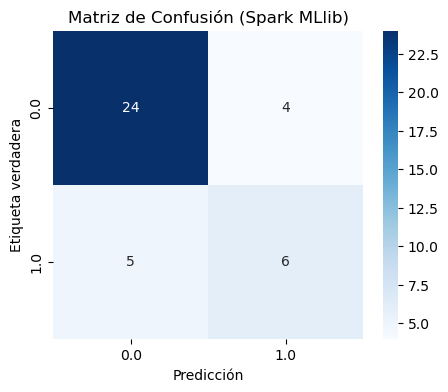

In [7]:
# Dibujar Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm_df, annot=True, fmt=".0f", cmap="Blues")
plt.title("Matriz de Confusión (Spark MLlib)")
plt.ylabel("Etiqueta verdadera")
plt.xlabel("Predicción")
plt.show()


In [8]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

roc_auc = evaluator.evaluate(pred)
print("AUC ROC:", roc_auc)


AUC ROC: 0.7857142857142856


In [9]:
model_path = "artefactos/modelo_spark_pima"
model.write().overwrite().save(model_path)
print(f"Modelo guardado en: {model_path}")


Modelo guardado en: artefactos/modelo_spark_pima


In [13]:
%%writefile streamlit_app.py

import streamlit as st
from pyspark.sql import SparkSession
from pyspark.ml import PipelineModel

# 1) SparkSession
spark = SparkSession.builder.appName("pima-streamlit").getOrCreate()

# 2) Cargar modelo entrenado
model_path = "artefactos/modelo_spark_pima"
model = PipelineModel.load(model_path)

st.title("Demo Diabetes (Pima) con Spark + Streamlit")

st.write("Predicción de diabetes (Yes/No) usando el modelo entrenado en Spark.")

# 3) Inputs (mismos features que el modelo)
npreg = st.number_input("Número de embarazos (npreg)", min_value=0, max_value=20, value=1)
glu   = st.number_input("Glucosa (glu)", min_value=0, max_value=300, value=120)
bp    = st.number_input("Presión sanguínea (bp)", min_value=0, max_value=200, value=70)
skin  = st.number_input("Grosor de piel (skin)", min_value=0, max_value=100, value=20)
bmi   = st.number_input("IMC (bmi)", min_value=0.0, max_value=70.0, value=30.0, step=0.1)
ped   = st.number_input("Pedigree (ped)", min_value=0.0, max_value=3.0, value=0.5, step=0.01)
age   = st.number_input("Edad (age)", min_value=18, max_value=90, value=35)

if st.button("Predecir"):
    # Crear DataFrame Spark de una fila
    input_df = spark.createDataFrame(
        [(npreg, glu, bp, skin, bmi, ped, age)],
        ["npreg", "glu", "bp", "skin", "bmi", "ped", "age"]
    )

    result = model.transform(input_df).select("probability", "prediction").collect()[0]
    prob = float(result["probability"][1])
    pred = int(result["prediction"])

    etiqueta = "Yes (diabetes)" if pred == 1 else "No (sin diabetes)"
    st.write(f"Predicción: **{etiqueta}**")
    st.write(f"Probabilidad de diabetes: **{prob:.2%}**")


Overwriting streamlit_app.py


In [1]:
%%writefile streamlit_app.py
import streamlit as st
from pyspark.sql import SparkSession
from pyspark.ml import PipelineModel

# 1) Cachear SparkSession
@st.cache_resource
def get_spark():
    spark = (
        SparkSession.builder
        .appName("pima-streamlit")
        .getOrCreate()
    )
    return spark

# 2) Cachear modelo (sin pasar spark como parámetro)
@st.cache_resource
def get_model():
    model_path = "artefactos/modelo_spark_pima"
    return PipelineModel.load(model_path)

# Instanciar recursos una sola vez
spark = get_spark()
model = get_model()

st.title("🧪 Demo Diabetes (Pima) con Spark + Streamlit")
st.write("Predicción con un modelo entrenado en Apache Spark (Pima.tr MASS).")

npreg = st.slider("Número de embarazos (npreg)", 0, 20, 2)
glu   = st.slider("Nivel de glucosa (glu)", 50, 250, 120)
bp    = st.slider("Presión arterial (bp)", 40, 130, 70)
skin  = st.slider("Espesor del pliegue cutáneo (skin)", 7, 100, 20)
bmi   = st.slider("IMC (bmi)", 10.0, 50.0, 25.0)
ped   = st.slider("Pedigree de diabetes (ped)", 0.0, 2.5, 0.5)
age   = st.slider("Edad (age)", 18, 90, 35)

if st.button("Predecir con Spark"):
    input_df = spark.createDataFrame(
        [(npreg, glu, bp, skin, bmi, ped, age)],
        ["npreg", "glu", "bp", "skin", "bmi", "ped", "age"]
    )

    result = model.transform(input_df).select("probability", "prediction").collect()[0]
    prob = float(result["probability"][1])
    pred = int(result["prediction"])

    etiqueta = "Diabética" if pred == 1 else "No diabética"
    st.write(f"Resultado: **{etiqueta}**")
    st.write(f"Probabilidad de diabetes: **{prob:.2%}**")


Overwriting streamlit_app.py


In [2]:
!streamlit run streamlit_app.py --server.port 8501 --server.address 0.0.0.0





  You can now view your Streamlit app in your browser.

  URL: http://0.0.0.0:8501

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/21 00:23:51 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/11/21 00:23:52 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
25/11/21 00:23:52 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
25/11/21 00:24:12 WARN StringIndexerModel: Input column type does not exist during transformation. Skip StringIndexerModel for this column.
25/11/21 00:24:13 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
25/11/21 00:24:20 WARN StringIndexerModel: Input column type does not exist during transformation. Skip StringIndexerModel for this column.
25/11/21 00:24:24 WARN StringIndexerModel: Input col